# Pixtral-8B Vision Two-Phase Evaluation on N48

Single model, two tasks:
1. Text extraction from image (OCR-style prompt)
2. Summarization from extracted text

Evaluation scope:
- Dataset subset: data/N30 (48 samples)
- Ground truth text + labels: data/synthetic/output/labels
- Phase 1 metrics: Accuracy, CER, WER, NED, Vocab-F1
- Phase 2 metrics: ROUGE, BERTScore, Medical term preservation

Run order:
1. Setup and imports
2. Model/prompt configuration
3. N48 data loading and preview
4. Phase 1 extraction + extraction metrics
5. Phase 2 summarization + summary metrics
6. Aggregated metrics report
7. Visualization

## 1. Setup and Imports

This section initializes the runtime environment and imports all local modules needed for extraction and summarization evaluation.

In [1]:
import sys
import json
import importlib
import logging
from pathlib import Path

import torch
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from transformers.utils import logging as hf_logging

# Suppress known harmless HF load warnings (e.g., bert-base-multilingual-cased cls.* heads).
hf_logging.set_verbosity_error()
logging.getLogger("transformers.modeling_utils").setLevel(logging.ERROR)

# Resolve project root robustly from either repo root or notebooks/ cwd.
cwd = Path.cwd()
if (cwd / 'src').exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / 'src').exists():
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd.parent.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

# Import our modules
import llm_processing.models as _models_mod
import llm_processing.llm_pipeline as _pipeline_mod
importlib.reload(_models_mod)
importlib.reload(_pipeline_mod)

from mistralai import Mistral
from llm_processing.prompts import get_prompt, PROMPTS
from evaluation.metrics import calculate_all_metrics
from evaluation.llm_metrics import (
    calculate_rouge_scores,
    calculate_bertscore,
    calculate_information_preservation,
)

print("✓ Imports successful")
print(f"  PROJECT_ROOT = {PROJECT_ROOT}")
print(f"  Torch: {torch.__version__}")
print("  HF model-loading warnings for known head-mismatch are suppressed")

/home/bashar/bachelor-thesis-nursing-agents/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Imports successful
  PROJECT_ROOT = /home/bashar/bachelor-thesis-nursing-agents
  Torch: 2.10.0+cu128
  HF model-loading warnings for known head-mismatch are suppressed


## 2. Model and Prompt Configuration

This section configures Mistral Pixtral-8B vision and defines the strict extraction prompt used for OCR-style transcription from images.

In [2]:
# -- Pixtral-8B vision setup + N48 Balanced Evaluation Set ----------------------
import os
import base64
import mimetypes

SCENARIOS_FILE    = PROJECT_ROOT / 'data' / 'synthetic' / 'scenarios.json'
SYNTHETIC_IMAGES  = PROJECT_ROOT / 'data' / 'synthetic' / 'output' / 'images'
SYNTHETIC_LABELS  = PROJECT_ROOT / 'data' / 'synthetic' / 'output' / 'labels'
N48_DIR           = PROJECT_ROOT / 'data' / 'N30'

with open(SCENARIOS_FILE, encoding='utf-8') as _f:
    scenarios = json.load(_f)
scenario_lookup = {s['patient']: s for s in scenarios if 'patient' in s}
print(f"Loaded {len(scenario_lookup)} scenarios with reference_summary\n")

# Same Pixtral-8B model for both tasks:
#   1) image -> extracted text (OCR-like extraction)
#   2) extracted text -> summary
api_key = os.getenv('MISTRAL_API_KEY')
if not api_key:
    raise EnvironmentError('MISTRAL_API_KEY is not set. Please export your Mistral API key before running this notebook.')

class PixtralVisionPipeline:
    def __init__(self, client, model_name='pixtral-12b-2409', max_tokens=1024, top_p=1.0):
        self.client = client
        self.model_name = model_name
        self.max_tokens = max_tokens
        self.top_p = top_p

    def _encode_image(self, image_path):
        image_path = Path(image_path)
        with open(image_path, 'rb') as f:
            encoded = base64.b64encode(f.read()).decode('utf-8')
        mime_type = mimetypes.guess_type(str(image_path))[0] or 'image/png'
        return f'data:{mime_type};base64,{encoded}'

    def _normalize_content(self, content):
        if isinstance(content, str):
            return content.strip()
        if isinstance(content, list):
            parts = []
            for block in content:
                if isinstance(block, dict) and 'text' in block:
                    parts.append(str(block['text']))
                elif isinstance(block, str):
                    parts.append(block)
            return '\n'.join(p.strip() for p in parts if p).strip()
        return str(content).strip() if content is not None else ''

    def process_image(self, image, user_prompt=None):
        prompt = user_prompt or 'Extract all visible text from this medical nursing note image exactly as written.'
        image_url = self._encode_image(image)
        response = self.client.chat.complete(
            model=self.model_name,
            temperature=0.0,
            top_p=self.top_p,
            max_tokens=self.max_tokens,
            messages=[
                {'role': 'system', 'content': 'You are a precise OCR assistant for medical nursing documentation.'},
                {'role': 'user', 'content': [
                    {'type': 'text', 'text': prompt},
                    {'type': 'image_url', 'image_url': image_url},
                ]},
            ],
        )
        return self._normalize_content(response.choices[0].message.content)

    def process_text(self, text):
        response = self.client.chat.complete(
            model=self.model_name,
            temperature=0.0,
            top_p=self.top_p,
            max_tokens=self.max_tokens,
            messages=[
                {'role': 'system', 'content': PROMPTS['nursing_prompt']['system']},
                {'role': 'user', 'content': PROMPTS['nursing_prompt']['task'].format(text=text)},
            ],
        )
        return self._normalize_content(response.choices[0].message.content)

client = Mistral(api_key=api_key)
pipeline = PixtralVisionPipeline(client=client, model_name='pixtral-12b-2409', max_tokens=1024, top_p=1.0)
print("✓ Pixtral-12B vision pipeline initialized\n")

EXTRACTION_PROMPT = """Du bist ein OCR-System fuer medizinische Pflegedokumentation.
Extrahiere den Text aus dem Bild so exakt wie moeglich.
WICHTIGE REGELN:
- Erfinde keine neuen Informationen.
- Fasse nicht zusammen und interpretiere nicht.
- Uebernimm Zahlen, Masseinheiten, Uhrzeiten, Medikamentennamen und Eigennamen exakt.
- Behalte Zeilenumbrueche und Reihenfolge so gut wie moeglich bei.
- Wenn ein Wort unklar ist, schreibe [UNK] statt zu raten.
Gib ausschliesslich den extrahierten Rohtext zurueck."""
print("✓ Extraction prompt configured")

Loaded 50 scenarios with reference_summary

✓ Pixtral-12B vision pipeline initialized

✓ Extraction prompt configured


## 3. N48 Dataset Loading and Preview

This section loads the 48 samples from `data/N30`, enriches metadata from labels, and displays a visual preview grid before evaluation.

N48 set: 48 samples  (24 fonts · balanced text lengths)



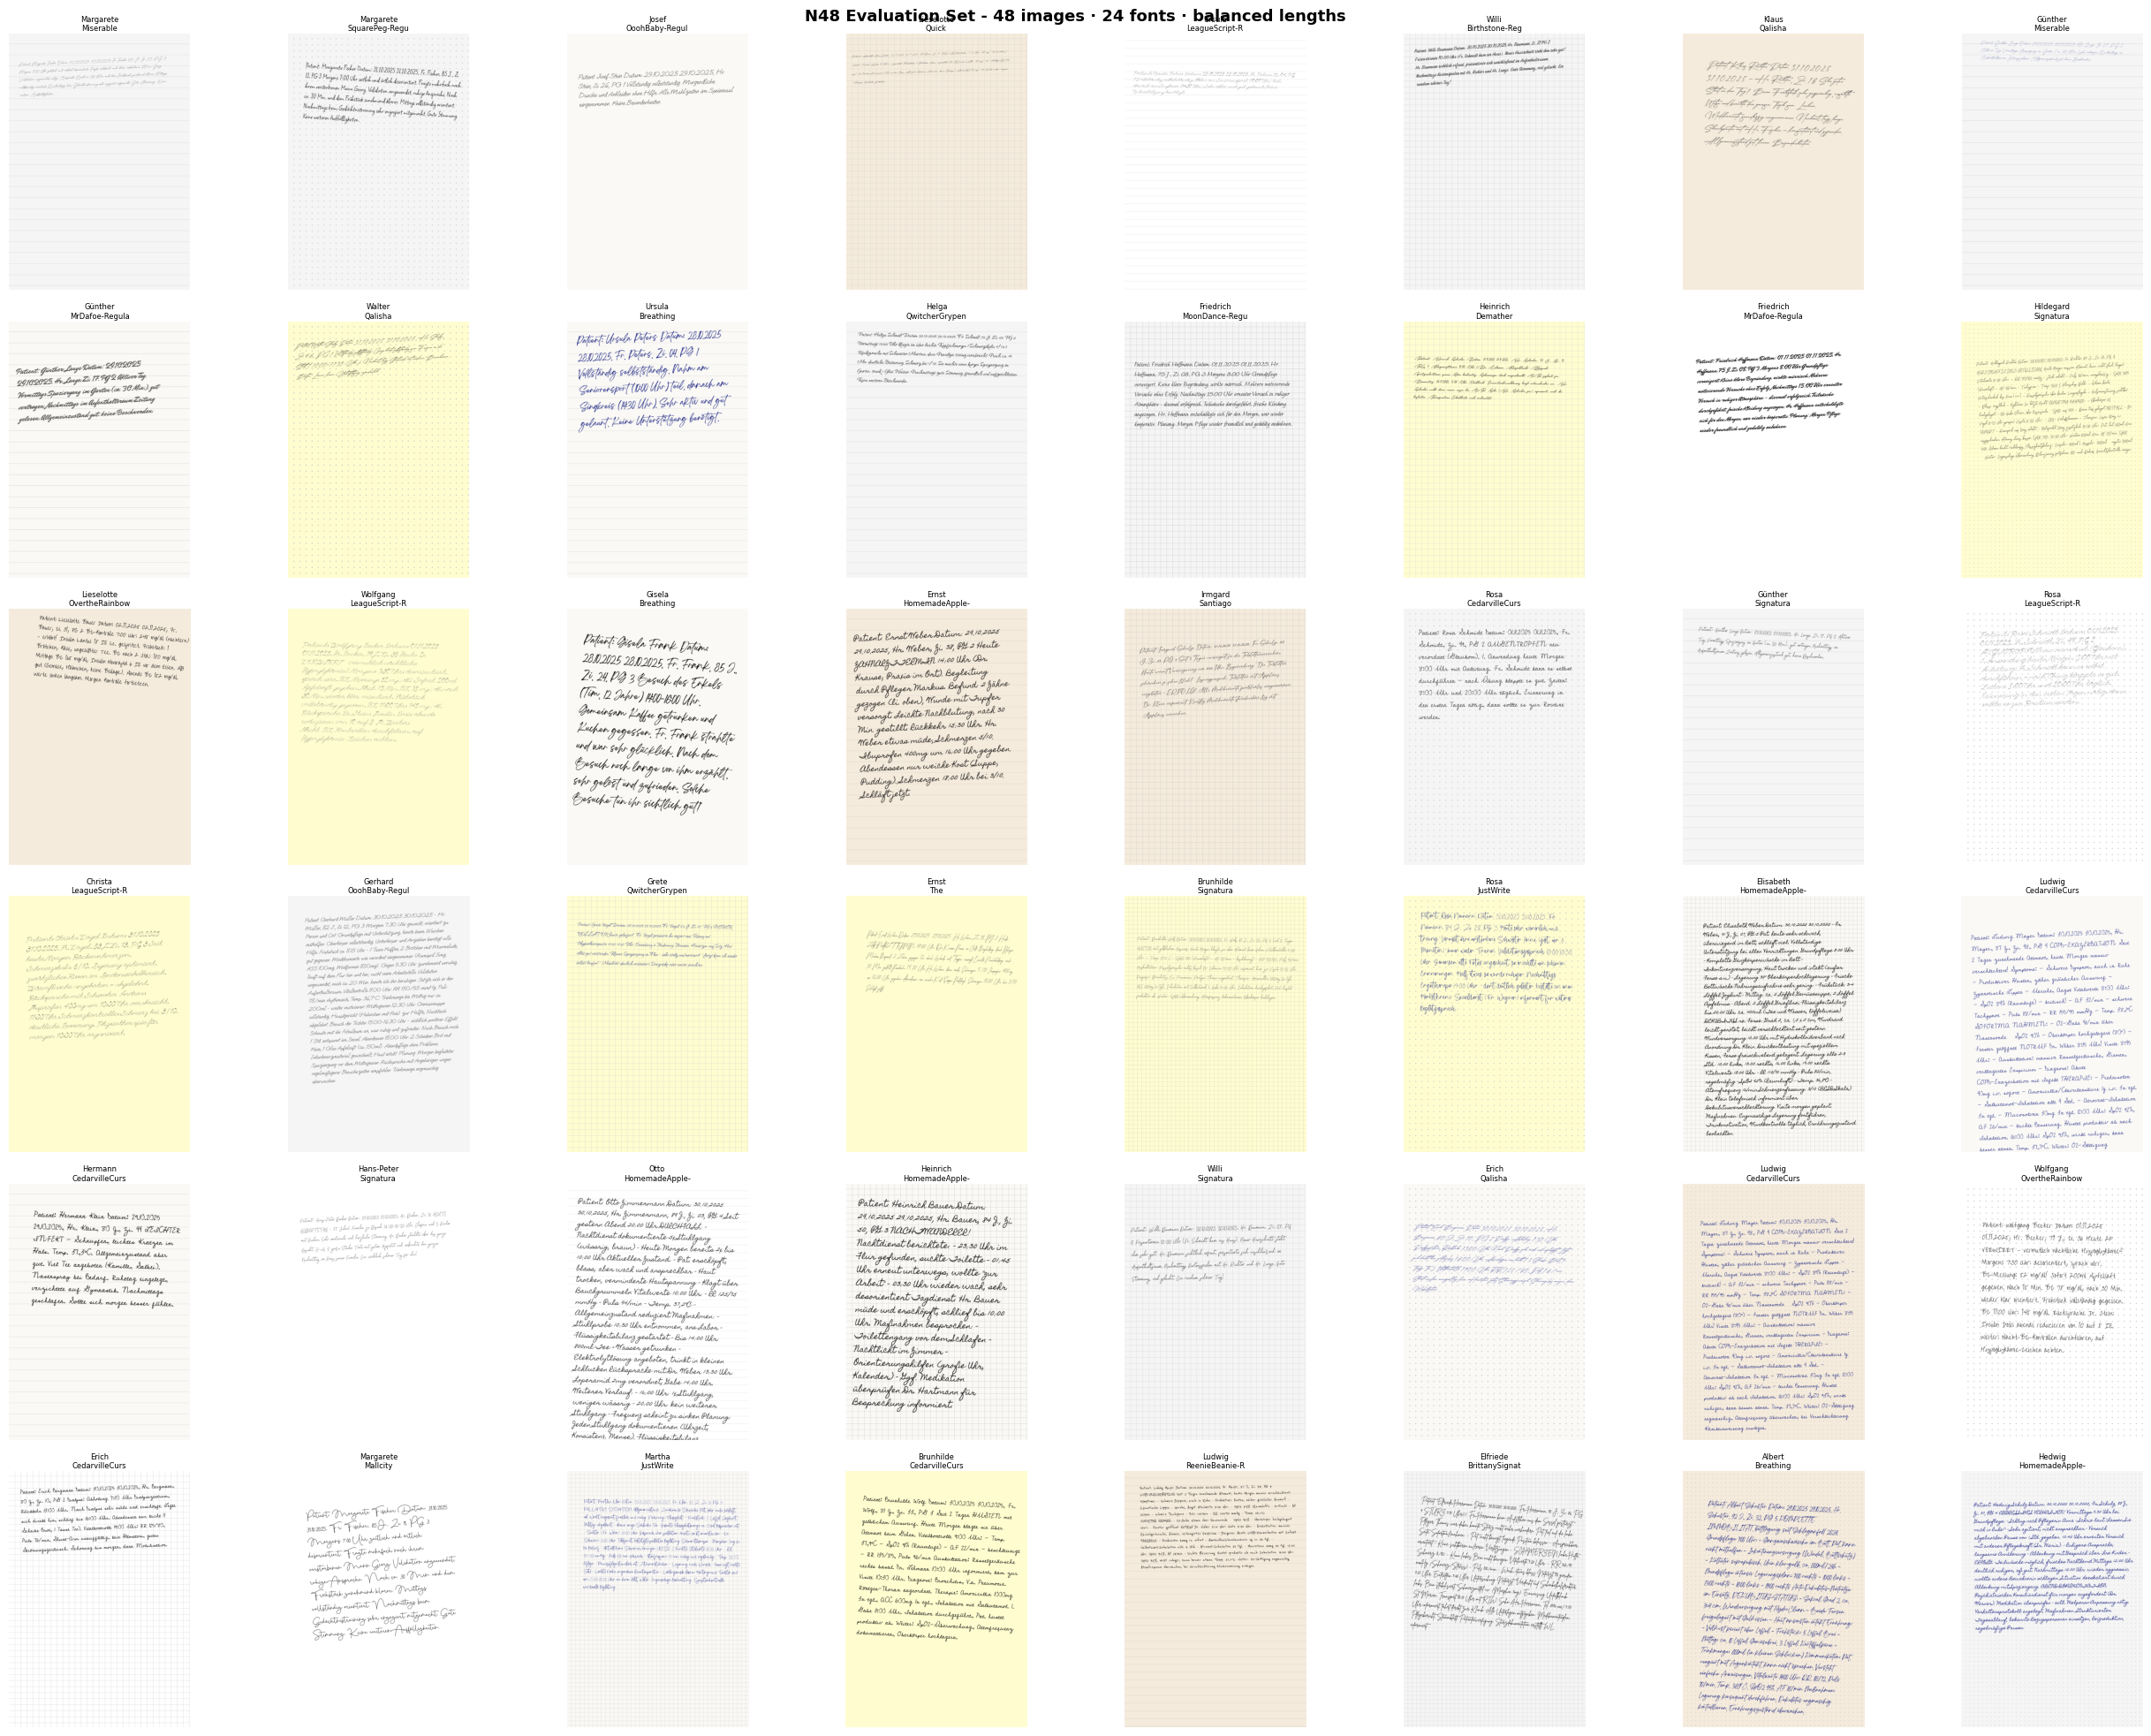

✓ 48 images previewed — run next cell for extraction + summarization


In [3]:
# 48 images: all 24 fonts covered, balanced across short/medium/long text lengths.
N48_SAMPLE_IDS = sorted(p.stem for p in N48_DIR.glob('*.png'))
print(f"N48 set: {len(N48_SAMPLE_IDS)} samples  (24 fonts · balanced text lengths)\n")

# Build metadata list directly from label files (no test_set indexing needed)
n48_samples_meta = []
for sid in N48_SAMPLE_IDS:
    lbl_path = SYNTHETIC_LABELS / f"{sid}.json"
    with open(lbl_path, encoding='utf-8') as _f:
        lbl = json.load(_f)
    font_file = os.path.basename(lbl['generation_parameters'].get('font_path', ''))
    n48_samples_meta.append({
        'sample_id': sid,
        'image_path': SYNTHETIC_IMAGES / f"{sid}.png",
        'label_path': str(lbl_path),
        'font': os.path.splitext(font_file)[0],
        'scenario': lbl.get('patient', ''),
        'full_text': lbl.get('full_text', ''),
    })

# -- Preview grid ---------------------------------------------------------------
n_cols, n_rows = 8, 6
fig, axes = plt.subplots(n_rows, n_cols, figsize=(26, 20))
fig.suptitle(
    f"N48 Evaluation Set - {len(N48_SAMPLE_IDS)} images · 24 fonts · balanced lengths",
    fontsize=13, fontweight='bold')

for ax, meta in zip(axes.flat, n48_samples_meta):
    img = Image.open(meta['image_path'])
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    font_short = meta['font'].split()[0][:14]
    patient_first = meta['scenario'].split()[0] if meta['scenario'] else 'NA'
    ax.set_title(f"{patient_first}\n{font_short}", fontsize=6, pad=2)

for ax in axes.flat[len(n48_samples_meta):]:
    ax.axis('off')

plt.tight_layout()
plt.show()
print(f"✓ {len(N48_SAMPLE_IDS)} images previewed — run next cell for extraction + summarization")

## 4. Phase 1 Extraction Evaluation

This section runs OCR-style extraction with Pixtral-8B vision on each image and evaluates extraction quality against full_text using Accuracy, CER, WER, NED, and Vocab-F1.

In [4]:
# -- Phase 1: extraction with Pixtral-8B vision ----------------------------------
print(f"Phase 1 (Extraction) batch: {len(n48_samples_meta)} samples\n")
print(f"{'#':>3}  {'Sample ID':<22} {'ACC':>7} {'CER':>7} {'WER':>7} {'NED':>7}")
print("─" * 72)

extraction_results = []

for i, meta in enumerate(n48_samples_meta):
    ref_text = meta.get('full_text', '')
    if not ref_text:
        print(f"{i+1:3d}  {meta['sample_id']:<22}  SKIPPED — missing full_text")
        continue

    try:
        extracted_text = pipeline.process_image(
            meta['image_path'],
            user_prompt=EXTRACTION_PROMPT,
        )
    except Exception as e:
        print(f"{i+1:3d}  {meta['sample_id']:<22}  EXTRACTION ERROR: {e}")
        continue

    ocr_metrics = calculate_all_metrics(ref_text, extracted_text)

    extraction_results.append({
        'sample_id': meta['sample_id'],
        'font': meta['font'],
        'scenario': meta['scenario'],
        'reference_text': ref_text,
        'extracted_text': extracted_text,
        **ocr_metrics,
    })

    print(f"{i+1:3d}  {meta['sample_id']:<22} "
          f"{ocr_metrics['accuracy']:>6.1f}% "
          f"{ocr_metrics['cer']:>6.1f}% "
          f"{ocr_metrics['wer']:>6.1f}% "
          f"{ocr_metrics['ned']:>6.1f}%")

print(f"\n✓ Phase 1 complete — {len(extraction_results)}/{len(n48_samples_meta)} samples processed")

Phase 1 (Extraction) batch: 48 samples

  #  Sample ID                  ACC     CER     WER     NED
────────────────────────────────────────────────────────────────────────
  1  sample_0002              20.0%   67.0%  100.0%   61.3%
  2  sample_0004              99.0%    0.7%    3.6%    0.7%
  3  sample_0005             100.0%    0.0%    0.0%    0.0%
  4  sample_0008               9.3%   70.4%   93.8%   59.9%
  5  sample_0009              82.7%   17.4%   36.4%   16.0%
  6  sample_0012              98.7%    1.7%    7.8%    1.7%
  7  sample_0014              40.0%    2.0%    8.5%    2.0%
  8  sample_0016              37.1%   36.5%   65.6%   36.5%
  9  sample_0018              98.1%    2.1%   15.6%    2.1%
 10  sample_0019              22.5%   54.9%   79.4%   48.3%
 11  sample_0020              99.6%    0.4%    3.0%    0.4%
 12  sample_0027              50.4%   10.8%   21.3%   10.8%
 13  sample_0047              99.8%    0.2%    1.6%    0.2%
 14  sample_0057              54.5%   17.3%   4

In [5]:
if not extraction_results:
    print("No extraction results to aggregate.")
else:
    df_ext = pd.DataFrame(extraction_results)
    print(f"Phase 1 (Extraction) Statistics — Pixtral-8B Vision  (N={len(df_ext)})\n")
    print(f"{'Metric':<20} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
    print("─" * 56)
    for label, col in [
        ('OCR Accuracy', 'accuracy'),
        ('OCR CER', 'cer'),
        ('OCR WER', 'wer'),
        ('OCR NED', 'ned'),
        ('OCR Vocab F1', 'vocab_f1'),
    ]:
        v = df_ext[col]
        print(f"{label:<20} {v.mean():>7.2f}% {v.std():>7.2f}% {v.min():>7.2f}% {v.max():>7.2f}%")


Phase 1 (Extraction) Statistics — Pixtral-8B Vision  (N=48)

Metric                   Mean      Std      Min      Max
────────────────────────────────────────────────────────
OCR Accuracy           79.74%   25.16%    9.28%  100.00%
OCR CER                 9.18%   16.27%    0.00%   70.43%
OCR WER                20.41%   23.26%    0.00%  100.00%
OCR NED                 8.67%   14.62%    0.00%   61.28%
OCR Vocab F1           83.13%   19.10%   23.53%  100.00%


## 7. Visualization

This section visualizes summary performance distributions with boxplots for ROUGE, BERTScore, and medical term preservation.

/tmp/ipykernel_9172/3603282469.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot(acc_data, labels=['Accuracy'], patch_artist=True)
/tmp/ipykernel_9172/3603282469.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot(err_data, labels=['CER', 'WER', 'NED'], patch_artist=True)


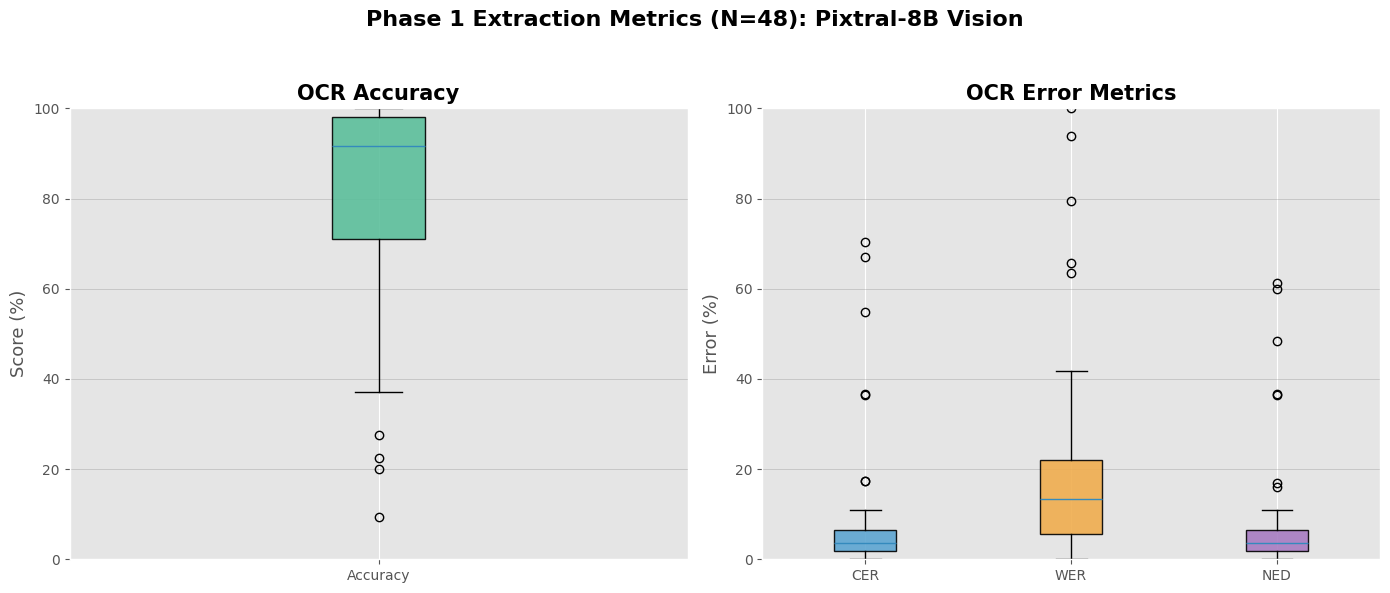

✓ Saved extraction plot: /home/bashar/bachelor-thesis-nursing-agents/output_test_pixtral8b_vision_extraction_metrics.png


In [6]:
# -- Visualization: extraction + summarization metrics --------------------------
plt.style.use('ggplot')

# Phase 1: OCR-style extraction metrics
if 'extraction_results' in globals() and extraction_results:
    df_ext = pd.DataFrame(extraction_results)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(
        f"Phase 1 Extraction Metrics (N={len(df_ext)}): Pixtral-8B Vision",
        fontsize=16,
        fontweight='bold',
    )

    # Left panel: OCR accuracy
    ax1 = axes[0]
    acc_data = [df_ext['accuracy']]
    bp1 = ax1.boxplot(acc_data, labels=['Accuracy'], patch_artist=True)
    for patch, color in zip(bp1['boxes'], ['#5cbf9b']):
        patch.set_facecolor(color)
        patch.set_alpha(0.9)
    ax1.set_ylabel('Score (%)', fontsize=13)
    ax1.set_title('OCR Accuracy', fontsize=15, fontweight='bold')
    ax1.set_ylim(0, 100)
    ax1.grid(axis='y', alpha=0.35, color='gray', linestyle='-', linewidth=0.6)

    # Right panel: OCR error metrics
    ax2 = axes[1]
    err_data = [df_ext['cer'], df_ext['wer'], df_ext['ned']]
    bp2 = ax2.boxplot(err_data, labels=['CER', 'WER', 'NED'], patch_artist=True)
    for patch, color in zip(bp2['boxes'], ['#5da5d1', '#f0ad4e', '#a77cc2']):
        patch.set_facecolor(color)
        patch.set_alpha(0.9)
    ax2.set_ylabel('Error (%)', fontsize=13)
    ax2.set_title('OCR Error Metrics', fontsize=15, fontweight='bold')
    ax2.set_ylim(0, 100)
    ax2.grid(axis='y', alpha=0.35, color='gray', linestyle='-', linewidth=0.6)

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    extraction_plot_path = PROJECT_ROOT / 'output_test_pixtral8b_vision_extraction_metrics.png'
    plt.savefig(extraction_plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved extraction plot: {extraction_plot_path}")
else:
    print('No extraction results available yet (extraction_results not found or empty).')
